
# PEC3: Deep Reinforcement Learning (II)


El objetivo de esta práctica es usar la librería de [stable baselines 3](https://stable-baselines3.readthedocs.io/en/master/) que ya implementa algoritmos de Reinforcement Learning para solucionar una versión modificada del cartpole, llamada cartpole target. Los objetivos de esta práctica son
<ol>
    <li>Desarrollar una capacidad analítica sobre cómo está funcionando el modelo.</li>
    <li>Familiarizarse con la librería stable baselines 3</li>
    <li>Analizar el efecto de modificar la función reward en el entrenamiento del agente</li>
    <li>Analizar el efecto de modificar el espacio de acciones </li>
    <li>Ser capaces de realizar una búsqueda de hiperparámetros. </li>
    <li>(Opcional) Familiarizarse con el análisis mediante tensorboard</li>
</ol>

# 0. Cartpole coin collection (2 ptos)

En esta práctica usaremos un entorno llamado cartpole coin collection. Este entorno está fuera de la librería gymnasium y es una modificación del entorno [cartpole](https://gymnasium.farama.org/environments/classic_control/cart_pole/). En este entorno, el objetivo no solo es mantener el poste estable sino que el carro debe recoger monedas que aparecen de forma aleatoria en el escenario. Cada vez que el carro recoge una moneda (al estar suficientemente cerca), aparece una nueva moneda en una posición aleatoria. Las monedas se visualizan marcadas en amarillo cuando se renderiza el entorno.

Existen algunos parámetros en el entorno que permiten regular qué tan importante es recoger las monedas versus mantener el poste estable.

In [1]:
import numpy as np
import matplotlib.pylab as plt

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 0.1 (0.75 ptos):</strong> Lee el código del entorno detenidamente. Ignorad todos los TODOS, son cosas que habrá que implementar a medida que la práctica avance. Después, responded a las siguientes preguntas:
     <ul>
      <li>¿Cuál es el espacio de observaciones? ¿Cómo se distingue respecto a la versión básica de cartpole?</li>
      <li>¿Qué dos versiones de la reward existen en el entorno? </li>
      <li>Para el caso en el que la reward es custom, ¿qué hace el parámetro coin_proximity_factor? ¿Y el parámetro coin_collection_reward?</li>
      <li>¿Por qué creéis que puede ser interesante el parámetro coin_proximity_factor como complemento al coin_collection_reward?
      <li>¿Cómo se determina si una moneda ha sido recogida?</li>
     </ul>
    
</div>

In [2]:
"""
Classic cart-pole system implemented by Rich Sutton et al.
Copied from http://incompleteideas.net/sutton/book/code/pole.c
permalink: https://perma.cc/C9ZM-652R
"""

import math
from typing import Optional, Union

import numpy as np

import gymnasium as gym
from gymnasium import spaces
from gymnasium.envs.classic_control import utils
from gymnasium.error import DependencyNotInstalled



class CartPoleEnvCoinCollection(gym.Env[np.ndarray, Union[int, np.ndarray]]):
    """
    ## Description

    This environment corresponds to a modification of the version of the cart-pole problem described by Barto, Sutton, and Anderson in
    ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077).
    A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track.
    The pendulum is placed upright on the cart and the goal is to balance the pole by applying forces
     in the left and right direction on the cart.
     The modification consists on coins appearing randomly in the scene. The cart must collect coins by getting close to them.
     When a coin is collected, a new one appears at a random position.

    For more details about original cartpole look for source code in gymnasium.
    """


    metadata = {
        "render_modes": ["human", "rgb_array"],
        "render_fps": 50,
    }

    def __init__(
        self,
        coin_proximity_factor: float = 0.5,
        coin_collection_reward:float = 10,
        reward_function: str = "default",
        is_eval=False,
        increased_actions=False,
        render_mode: Optional[str] = None,
    ):

        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.5  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.tau = 0.02  # seconds between state updates

        self.max_steps = 500
        self.steps = 0

        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4
        self.coin_threshold = 2
        self.coin_collection_distance = 0.05  # Distance to collect a coin

        high = np.array(
            [
                self.x_threshold * 2,
                np.inf,
                self.theta_threshold_radians * 2,
                np.inf,
                self.coin_threshold * 2,
            ],
            dtype=np.float32,
        )
        self.increased_actions = increased_actions
        if self.increased_actions:
            #TODO 3.1: Ampliar espacio de observaciones
            #raise NotImplementedError("Increased actions should be implemented")
            self.action_space = spaces.Discrete(6)
        else:
            self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.render_mode = render_mode

        self.screen_width = 600
        self.screen_height = 400
        self.screen = None
        self.clock = None
        self.isopen = True
        self.state: np.ndarray | None = None

        self.steps_beyond_terminated = None

        #TODO 1.3: Tener en cuenta si el entorno es de evaluacion
        self.is_eval = is_eval

        # definimos las 9 posiciones fijas
        self.eval_coin_positions = np.array([
            -self.x_threshold,
            -0.75 * self.x_threshold,
            -0.5 * self.x_threshold,
            -0.25 * self.x_threshold,
             0.0,
             0.25 * self.x_threshold,
             0.5 * self.x_threshold,
             0.75 * self.x_threshold,
             self.x_threshold,
        ])
            
        self.coin_position = self.generate_random_coin_position()
        self.coins_collected = 0

        self.coin_proximity_factor = min(
            max(coin_proximity_factor, 0), 1
        )  # between 0 and 1
        self.coin_collection_reward = coin_collection_reward
        if reward_function in ["default", "custom", "custom_1", "custom_2"]:
            self.reward_function = reward_function
        else:
            raise AttributeError("reward function must be either default or custom")

    def generate_random_coin_position(
        self,
    ):
        if self.is_eval:
            #TODO 1.3: Tener en cuenta si el entorno es de evaluacion para situar la moneda en unas posiciones concretas.
            # posición aleatoria entre las 9 posibles
            return self.np_random.choice(self.eval_coin_positions)
        else:
            return np.random.uniform(-self.x_threshold, self.x_threshold)

    def custom_reward(self, coin_position, current_position, angle, terminated, coin_collected):
        if self.reward_function == "default":
            #Reward default del cartpole
            return 1 if not terminated else 0
        #TODO 2.2: Implementar 2 funciones de reward extras
        elif self.reward_function == "custom_1":
            collection_bonus = self.coin_collection_reward if coin_collected else 0.0
            return 1 + collection_bonus
        elif self.reward_function == "custom_2":
            dist = abs(current_position - coin_position) / self.x_threshold
            coin_proximity_reward = (1 - dist) ** 2
            collection_bonus = self.coin_collection_reward if coin_collected else 0.0
            return 1 + self.coin_proximity_factor * coin_proximity_reward + collection_bonus
        
        else:
            angle_reward = (
                -abs(angle) / (2.0 * self.x_threshold) / self.theta_threshold_radians
            )
            coin_proximity_reward = -(abs(coin_position - current_position) ** 2) / (
                (2 * self.x_threshold) ** 2
            )
            # Bonus por recoger moneda
            collection_bonus = self.coin_collection_reward if coin_collected else 0.0

            return (
                1
                + self.coin_proximity_factor * (coin_proximity_reward)
                + (1 - self.coin_proximity_factor) * angle_reward
                + collection_bonus
            )

            

    def step(self, action):
        assert self.action_space.contains(
            action
        ), f"{action!r} ({type(action)}) invalid"
        assert self.state is not None, "Call reset before using step method."
        x, x_dot, theta, theta_dot, _ = self.state
        if self.increased_actions:
            #forces = [-1.0, -0.66, -0.33, 0.33, 0.66, 1.0]
            #force = forces[action] * self.force_mag
            # no se si esta parte se debe cambiar o no
            force_factor = action - 3
            force = (
                force_factor / 3 * self.force_mag
                if force_factor > 0
                else (force_factor - 1) / 3 * self.force_mag
            )
        else:
            force = self.force_mag if action == 1 else -self.force_mag
        costheta = np.cos(theta)
        sintheta = np.sin(theta)

        # For the interested reader:
        # https://coneural.org/florian/papers/05_cart_pole.pdf
        temp = (
            force + self.polemass_length * np.square(theta_dot) * sintheta
        ) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length
            * (4.0 / 3.0 - self.masspole * np.square(costheta) / self.total_mass)
        )
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        x = x + self.tau * x_dot
        x_dot = x_dot + self.tau * xacc
        theta = theta + self.tau * theta_dot
        theta_dot = theta_dot + self.tau * thetaacc

        # Check if coin collected
        coin_collected = False
        if abs(x - self.coin_position) < self.coin_collection_distance:
            coin_collected = True
            self.coins_collected += 1
            self.coin_position = self.generate_random_coin_position()

        self.state = np.array(
            (x, x_dot, theta, theta_dot, self.coin_position), dtype=np.float64
        ) #Este state difiere del del cartpole original

        terminated = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
        )

        reward = self.custom_reward(self.coin_position, x, theta, terminated, coin_collected)

        if self.render_mode == "human":
            self.render()

        # truncation=False as the time limit is handled by the `TimeLimit` wrapper added during `make`
        self.steps += 1
        if self.steps >= self.max_steps:
            truncated = True
        else:
            truncated = False
        return np.array(self.state, dtype=np.float32), reward, terminated, truncated, {}

    def reset(
        self,
        *,
        seed: Optional[int] = None,
        options: Optional[dict] = None,
    ):

        super().reset(seed=seed)
        self.steps = 0
        self.coins_collected = 0
        # Note that if you use custom reset bounds, it may lead to out-of-bound
        # state/observations.
        low, high = utils.maybe_parse_reset_bounds(
            options, -0.05, 0.05  # default low
        )  # default high

        self.state = self.np_random.uniform(low=low, high=high, size=(4,)).tolist()
        self.steps_beyond_terminated = None

        #Generar posicion random de la moneda y guardar en el estado
        self.coin_position = self.generate_random_coin_position()
        self.state.append(self.coin_position)

        self.state = np.array(self.state)
        if self.render_mode == "human":
            self.render()
        return np.array(self.state, dtype=np.float32), {}

    def render(self):
        if self.render_mode is None:
            assert self.spec is not None
            gym.logger.warn(
                "You are calling render method without specifying any render mode. "
                "You can specify the render_mode at initialization, "
                f'e.g. gym.make("{self.spec.id}", render_mode="rgb_array")'
            )
            return

        try:
            import pygame
            from pygame import gfxdraw
        except ImportError as e:
            raise DependencyNotInstalled(
                'pygame is not installed, run `pip install "gymnasium[classic-control]"`'
            ) from e

        if self.screen is None:
            pygame.init()
            if self.render_mode == "human":
                pygame.display.init()
                self.screen = pygame.display.set_mode(
                    (self.screen_width, self.screen_height)
                )
            else:  # mode == "rgb_array"
                self.screen = pygame.Surface((self.screen_width, self.screen_height))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        world_width = self.x_threshold * 2
        scale = self.screen_width / world_width
        polewidth = 10.0
        polelen = scale * (2 * self.length)
        cartwidth = 50.0
        cartheight = 30.0
        coinradius = 8

        if self.state is None:
            return None

        x = self.state

        self.surf = pygame.Surface((self.screen_width, self.screen_height))
        self.surf.fill((255, 255, 255))

        l, r, t, b = -cartwidth / 2, cartwidth / 2, cartheight / 2, -cartheight / 2
        axleoffset = cartheight / 4.0
        cartx = x[0] * scale + self.screen_width / 2.0  # MIDDLE OF CART
        carty = 100  # TOP OF CART
        cart_coords = [(l, b), (l, t), (r, t), (r, b)]
        cart_coords = [(c[0] + cartx, c[1] + carty) for c in cart_coords]
        gfxdraw.aapolygon(self.surf, cart_coords, (0, 0, 0))
        gfxdraw.filled_polygon(self.surf, cart_coords, (0, 0, 0))

        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )

        pole_coords = []
        for coord in [(l, b), (l, t), (r, t), (r, b)]:
            coord = pygame.math.Vector2(coord).rotate_rad(-x[2])
            coord = (coord[0] + cartx, coord[1] + carty + axleoffset)
            pole_coords.append(coord)
        gfxdraw.aapolygon(self.surf, pole_coords, (202, 152, 101))
        gfxdraw.filled_polygon(self.surf, pole_coords, (202, 152, 101))

        gfxdraw.aacircle(
            self.surf,
            int(cartx),
            int(carty + axleoffset),
            int(polewidth / 2),
            (129, 132, 203),
        )
        gfxdraw.filled_circle(
            self.surf,
            int(cartx),
            int(carty + axleoffset),
            int(polewidth / 2),
            (129, 132, 203),
        )

        # Draw coin
        coinx = x[-1] * scale + self.screen_width / 2.0  # MIDDLE OF coin
        coiny = 90  # Y position of coin
        gfxdraw.aacircle(
            self.surf,
            int(coinx),
            int(coiny),
            coinradius,
            (255, 215, 0),  # Gold color
        )
        gfxdraw.filled_circle(
            self.surf,
            int(coinx),
            int(coiny),
            coinradius,
            (255, 215, 0),  # Gold color
        )

        gfxdraw.hline(self.surf, 0, self.screen_width, carty, (0, 0, 0))

        self.surf = pygame.transform.flip(self.surf, False, True)
        self.screen.blit(self.surf, (0, 0))
        if self.render_mode == "human":
            pygame.event.pump()
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        elif self.render_mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )

    def close(self):
        if self.screen is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
    
- ¿Cuál es el espacio de observaciones? ¿Cómo se distingue respecto a la versión básica de cartpole?

El juego es una versión modificada del cartpole en la que además del carro que mueve un palo, este también tendrá que recoger unas monedas que aparecen en el espacio de juego. El espacio de observaciones del entorno son vectores con la forma [x, x_dot, theta, theta_dot, coin_position]
siendo:
x: posición del carro
x_dot: velocidad del carro
theta: ángulo del palo
theta_dot: velocidad del palo
coin_position: posición de la moneda

- ¿Qué dos versiones de la reward existen en el entorno?

La primera recomensa definida como  -abs(angle) / (2.0 * self.x_threshold) / self.theta_threshold_radians es la recompensa clásica del juego de cartpole. Además de esto está la recompensa de las monedas, que se calcula en base a la distancia del carro a la moneda y si este la ha recogido o no.

- Para el caso en el que la reward es custom, ¿qué hace el parámetro coin_proximity_factor? ¿Y el parámetro coin_collection_reward?

El coin_proximity_factor es un factor fijo entre 0 y 1 con el que se calcula la recompensa de la recogida de monedas como 
                1
                + self.coin_proximity_factor * (coin_proximity_reward)
                + (1 - self.coin_proximity_factor) * angle_reward
                + collection_bonus
El factor coin_collection_reward es un parámetro fijo que se suma con (y es equivalente a) collection_bonus, solo si el carro  ha recogido la moneda.

- ¿Por qué creéis que puede ser interesante el parámetro coin_proximity_factor como complemento al coin_collection_reward?

El factor de proximidad a la moneda permitirá al agente tener mejores incentivos para acercarse a la moneda, en lugar de solo ser recompensado al recogerla, también se le recompensará en menor medida si se acerca a ella.

- ¿Cómo se determina si una moneda ha sido recogida?

Se determina un parámetro de distancia de recogida de la moneda y después en el step se compara la posición x del carro con la posición de la moneda. tal que si está a una distancia menor a la definida se toma como recogida.
  
<br><br>
</div>

<strong>IMPORTANTE: PARA LOS APARTADOS 1 Y 2 HAREMOS SERVIR LA REWARD DEFAULT.</strong> Esto implica que nuestro entorno sera el mismo que el del cartpole classico sin considerar las monedas.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 0.2 (0.75 ptos):</strong> Ejecuta el entorno cartpole coin collection usando una policy random. Guarda las observaciones en una lista y posteriormente crea una función para analizar los resultados donde se vea:
    <ul>
    <li>Un scatter plot de la posición relativa del carro respecto a la moneda (eje x) y los ángulos del poste (eje y). En el scatter plot marcad distinto el punto inicial y el final para poder saber cuándo empieza y termina el episodio. De forma opcional, cada punto lo podéis marcar distinto según la acción tomada (empujar izquierda o derecha). Por ejemplo una cruz si se empuja a la derecha y un círculo si se hace hacia la izquierda.</li>
    <li>La evolución del reward a lo largo del episodio (acumulado y reward punto a punto).</li>
    <li>Printear el número de episodios realizados y monedas recogidas.</li>
    </ul>   
Comenta los resultados encontrados.

<strong>NOTA: Para poder ver cómo el agente va moviendo el Pole de forma interactiva, podéis usar render_mode = 'human'. Esto NO se debe hacer cuando se entrenen los modelos, pues estos serán muy lentos de entrenar.

 No es obligatorio usar render mode = 'human' para las evaluaciones, pero puede ser interesante. En caso de querer hacerlo, recordad que hay que ejecutar en local.
 </strong>

![ejemplo_grafica](ejemplo_grafica.png)
</div>

In [3]:
import gymnasium as gym
import time

In [4]:
#TODO: Completar codigo
# he tenido que cambiar el render_mode ya que en modo human, la ventana del juego crasheaba y mataba el kernel
env = CartPoleEnvCoinCollection(render_mode='none',reward_function = 'default')

total_reward = 0
done = False 
obs, _ = env.reset()

observations = []
actions = []
rewards = []

while not done:
    # Escoger una acción aleatoria
    action = env.action_space.sample()
    # Ejecutar la acción y esperar la respuesta del entorno
    new_obs, reward, terminated, truncated, _ = env.step(action)
    
    done = (terminated or truncated)
    total_reward += reward
    
    # Guardar informacion necesaria para poder hacer los plots despues
    observations.append(obs)
    actions.append(action)
    rewards.append(reward)

    obs = new_obs


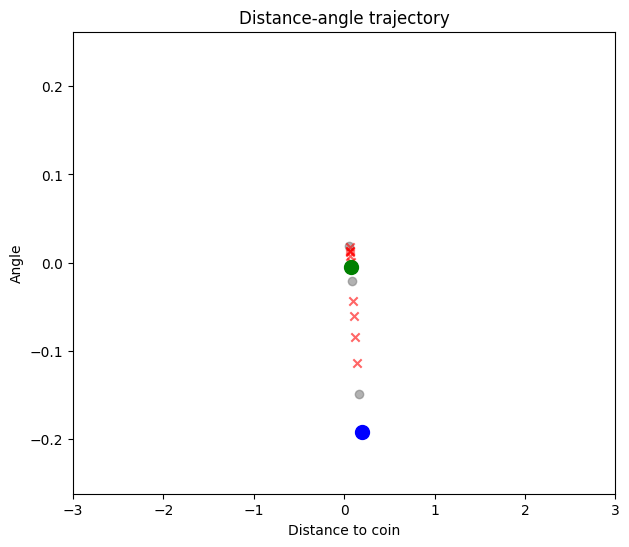

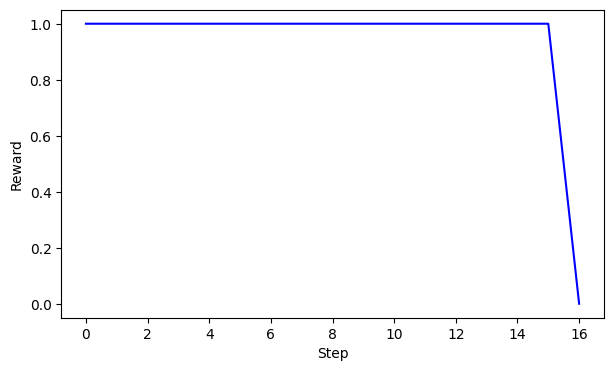

Episode length: 17
Coins collected: 0


In [5]:
X_THRESHOLD = env.unwrapped.x_threshold*1.25 #Limite por donde se puede mover el carro
ANGLE_THRESHOLD = env.unwrapped.theta_threshold_radians*1.25 #Limite del angulo del palo
def analyze_results(data):
    #TODO: Completar codigo
    # se recibe {obs, actions, rewards}
    obs = data["observations"]
    actions = data["actions"]
    rewards = data["rewards"]

    x = obs[:, 0]
    theta = obs[:, 2]
    coin_pos = obs[:, 4]

    distance_to_coin = x - coin_pos

    left_mask = actions == 0
    right_mask = actions == 1

    plt.figure(figsize=(7, 6))

    # a la izquierda - círculo gris
    plt.scatter(
        distance_to_coin[left_mask],
        theta[left_mask],
        marker='o',
        c='gray',
        alpha=0.6,
        label='Push left'
    )
    
    # a la derecha - cruz roja
    plt.scatter(
        distance_to_coin[right_mask],
        theta[right_mask],
        marker='x',
        c='red',
        alpha=0.6,
        label='Push right'
    )

    # puntos inicial y final
    plt.scatter(
        distance_to_coin[0],
        theta[0],
        c='green',
        s=100,
        label='Start'
    )

    plt.scatter(
        distance_to_coin[-1],
        theta[-1],
        c='blue',
        s=100,
        label='End'
    )

    # grafica distancia a moneda
    plt.plot()
    plt.xlabel('Distance to coin')
    plt.ylabel('Angle')
    plt.ylim(-ANGLE_THRESHOLD,ANGLE_THRESHOLD)
    plt.xlim(-X_THRESHOLD,X_THRESHOLD)
    plt.title('Distance-angle trajectory')
    plt.show()

    # grafica recompensa por step
    plt.figure(figsize=(7, 4))
    plt.plot(rewards, color='blue')
    plt.xlabel('Step')
    plt.ylabel('Reward')
    plt.show()


    print (f'Episode length: {len(rewards)}')
    print (f'Coins collected: {env.coins_collected}')

    return

#TODO: pasar inputs necesarios
analyze_results({
    "observations": np.array(observations),
    "actions": np.array(actions),
    "rewards": np.array(rewards)
})

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>El agente se ha movido de forma aleatoria a izquierda y derecha durante 46 steps (en esta ejecución) hasta que ha perdido la partida, momento en el que la reward baja de 1 a 0. No ha recogido ninguna moneda, y si lo hubiera hecho, habría sido por casualidad, ya que no se le estaría recompensando por ello. No pueden sacarse muchas conclusiones sobre una política aleatoria ya que tanto en el caso de perder la partida en muy pocos steps como en el de aguantar muchos, no sería gracias a la política del agente si no al rng.<br>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 0.3 (0.5 ptos):</strong> Respecto al gráfico realizado en el apartado anterior, ¿cuál es la trayectoria que realizaría un agente que se comportase de forma óptima?
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>Un agente óptimo alternará movimientos a izquierda y derecha que minimizen el movimiento del palo y lo mantengan en equilibrio, pero moviendose en mayor proporción en la dirección en la que haya una moneda. En la primera gráfica se vería una línea que alterna x y o y que se desplaza hacia distance_to_coin = 0, y que idealmente se mantiene cerca de angle=0.<br>
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 0:</strong>
<br><br>
Aprendizaje automático - PEC2
    
https://gymnasium.farama.org/environments/classic_control/cart_pole/
</div>

# 1. Stable baselines 3 (2 ptos)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    Vamos a empezar a entrenar un modelo para solucionar el entorno. Recordad que para los apartados 1 y 2 usaremos la reward default.
    Para solucionar el entorno vamos a usar el modelo A2C de la libreria stable baselines.
</div

In [6]:
from stable_baselines3 import A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback
STEPS = 20_000
EVAL_FREQ = 2000
EVAL_EPISODES = 5

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 1.1 (0.25 ptos):</strong> Entrena un modelo A2C con parámetros default y usando una MlpPolicy para entrenar un agente que solucione el cartpole con reward default.
    Añade un callback para evaluar el modelo 5 veces cada 2 mil iteraciones, guardando el mejor modelo hasta el momento.
    Además, haz que cada vez que se encuentre un modelo mejor se guarde el modelo. Inicialmente, antes de empezar el training, usa la función evaluate_policy para evaluar el modelo sin entrenar. 
    Al final, carga el mejor modelo encontrado. Vuelve a usar la función evaluate_policy con el modelo cargado y compara resultados iniciales y finales.
</div>

Opcional: Para los que queráis profundizar un poco más en la asignatura, existe también una herramienta llamada tensorboard muy útil para analizar el proceso de training de cualquier red neuronal en general. Stable baselines 3 tiene automatizado la captura de logs con tensorboard. Para hacerlo, solo necesitáis pasarle al constructor del modelo el parámetro tensorboard_log= path donde queráis guardar el log. Podéis usar estos logs para mirar no solo los rewards de evaluación sino para ver los gradientes, la loss y otros parámetros durante el training.

Podéis usarlo en este apartado y en todos los que queráis durante la práctica. No puntuará ni se tendrá en cuenta, pero permite conocer más en detalle cómo está entrenando el modelo.

In [7]:
env = CartPoleEnvCoinCollection(render_mode=None, reward_function = 'default')

callback = EvalCallback(
    env,
    best_model_save_path="./best_model/",
    eval_freq=EVAL_FREQ,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True,
    render=False
)

model = A2C(
    policy="MlpPolicy",
    env=env,
    verbose=1
)

initial_eval = evaluate_policy(
    model,
    env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)


print(f"initial eval: {initial_eval[0]:.2f} ± {initial_eval[1]:.2f}")

# entrenar modelo
model.learn(
    total_timesteps=STEPS,
    callback=callback
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\Usuario\Desktop\UOC\uocvenv\Lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


initial eval: 8.40 ± 0.49
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 19       |
|    ep_rew_mean        | 18       |
| time/                 |          |
|    fps                | 1272     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.687   |
|    explained_variance | 0.0188   |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.0379  |
|    value_loss         | 1.08     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 23.5     |
|    ep_rew_mean        | 22.5     |
| time/                 |          |
|    fps                | 1331     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps    | 1000     |
| train/    

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 1.2 (0.25 ptos):</strong> Carga el mejor modelo encontrado y ejecuta la función evaluate policy. Compara los rewards iniciales y finales.
     Ejecuta un episodio y analiza los resultados usando la función previamente creada para visualizar el comportamiento del agente en el espacio de ángulo-posición.
</div>

In [8]:
model = A2C.load("./best_model/best_model", env=None) #cargar el mejor modelo

# evaluamos 
final_eval = evaluate_policy(
    model,
    env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)

print (f'initial evaluation: {initial_eval}')
print (f'best model evaluation: {final_eval}')

initial evaluation: (np.float64(8.4), np.float64(0.48989794855663565))
best model evaluation: (np.float64(500.0), np.float64(0.0))


In [9]:
#TODO: Completar funcion de evaluacion del modelo entrenado
def evaluate_trained_model(env,model):
    #Primero ejecutamos una vez el entorno
    obs,_ = env.reset()
    done = False
    
    observations = []
    actions = []
    rewards = []
    
    while not done:
        # Escoger una acción en base al modelo
        action, _ = model.predict(obs, deterministic=True)
        
        # Ejecutar la acción y esperar la respuesta del entorno
        new_obs, reward, terminated, truncated, _ = env.step(action)

        # Guardar informacion necesaria para poder hacer los plots despues
        observations.append(obs)
        actions.append(action)
        rewards.append(reward)

        obs = new_obs
        done = terminated or truncated
    data = {
        "observations": np.array(observations),
        "actions": np.array(actions),
        "rewards": np.array(rewards)
    }

    #Analizamos los resultados
    analyze_results(data)


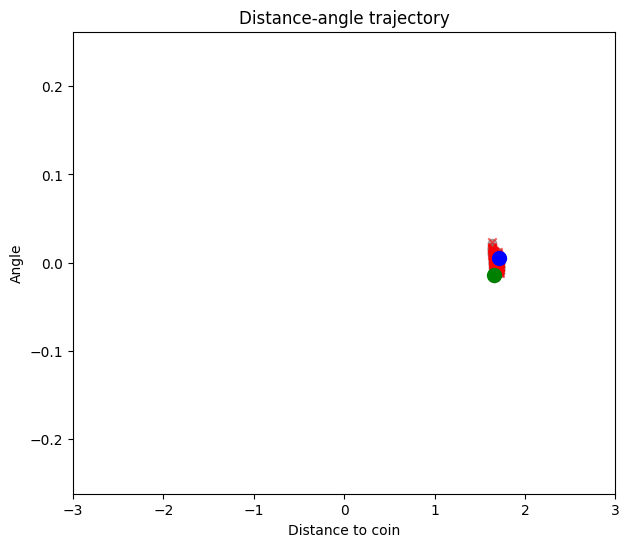

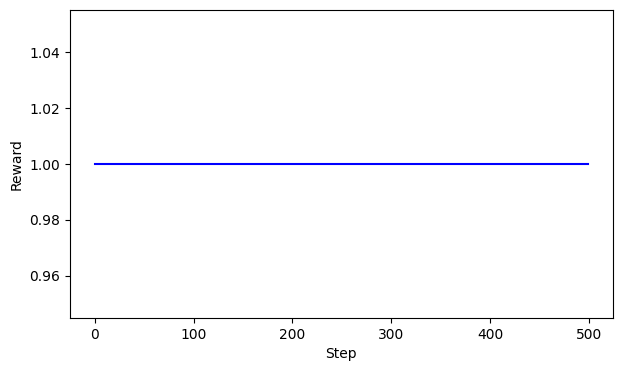

Episode length: 500
Coins collected: 0


In [10]:
env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'default') #podeis hacer render mode = None
evaluate_trained_model(env,model)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>En esta ejecución la partida ha terminado por truncamiento ya que ha llegado a los 500 steps. El agente se mueve a izquierda y derecha formando una linea muy constante al rededor de angle=0 (que no se aprecia muy claramente en la gráfica), sin recoger ninguna moneda (lo que habría sido casualidad ya que no se le está recompensando por ello), lo que significa que el agente ha aprendido a optimizar el movimiento del carro para mantener el palo lo más recto posible de forma indefinida, que es el objetivo del juego sin la modificación de añadido de monedas.<br>
    
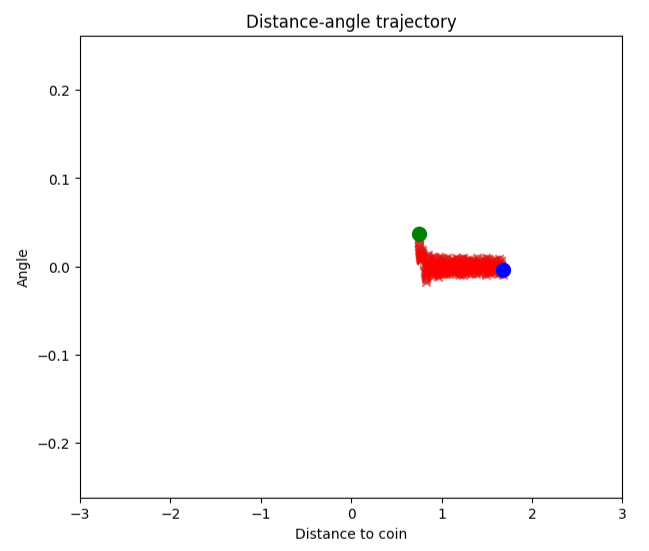
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 1.3 (0.5 pto):</strong> Uno de los problemas que tenemos con este entorno es que estamos evaluando el modelo sobre un entorno random. Esto genera que durante el callback podemos guardar un modelo no porque sea mejor que los anteriores sino porque los entornos sobre los que se ha evaluado son más sencillos. Por ejemplo, si en uno de los callbacks la moneda se sitúa en los extremos, aunque el agente se sepa comportar mejor que sus anteriores versiones, puede que no lo sepamos debido a que el reward total será menor que, por ejemplo, una versión con un peor comportamiento pero que la moneda se ha situado en el centro.
    Modifica el entorno de cartpole (ver TODOS dentro del código) para que en evaluación la moneda aparezca en 9 posiciones distintas de forma aleatoria cada vez que se resetea el entorno o cada vez que se recoge una moneda:
    <ul>
    <li> En los extremos</li>
    <li> a 3/4,1/2 y 1/4 de la distancia entre el centro</li>
    <li> Justo en el centro</li>
    </ul>
    Setearemos a partir de ahora el número de episodios de evaluación a 20 (EVAL_EPISODES) para tener una evaluación suficientemente robusta.
    Nota: Esto no tendrá efecto en este apartado, pues estamos usando la reward default. Sin embargo, para las rewards custom, el entorno de evaluación es crítico
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 1.4.1 (0.5 ptos):</strong> Modifica la función analyze_results (o crea otra, como prefieras) para analizar las ejecuciones de evaluación de forma simultánea. Crea:
    <ul>
    <li> El mismo gráfico que antes de la trayectoria (distancia vs ángulo) pero superponiendo todos los entornos de evaluación</li>
    <li> Un boxplot del reward conseguido total. En el título que se muestre el promedio</li>
    <li> Un boxplot del número de coins conseguidos. En el título que se muestre el promedio</li>
    <li> Un boxplot con la longitud del episodio. En el título que se muestre el promedio.</li>
    </ul>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 1.4.2 (0.5 ptos):</strong> Repite los ejercicios 1.1 y 1.2 pero evaluando con un entorno de evaluación y usando la nueva función de evaluación.
</div>

In [11]:
#Hay que modificar primero los TODO del entorno
EVAL_EPISODES = 20
env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'default')
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'default',is_eval = True)

#TODO: Completar codigo
#Creamos callback, modelo. Para el callback usamos entorno de evaluacion, para el modelo el normal.
callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model/",
    eval_freq=EVAL_FREQ,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True,
    render=False
)

model = A2C(
    policy="MlpPolicy",
    env=env,
    verbose=1
)

#Ejecutamos evaluacion inicial y entrenamos el modelo

initial_eval = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)
model.learn(
    total_timesteps=STEPS,
    callback=callback
)

#Cargamos el mejor modelo y ejecutamos evaluacion final
model = A2C.load("./best_model/best_model", env=None) #cargar el mejor modelo
final_eval = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)
print (f'initial evaluation: {initial_eval}')
print (f'Best model evaluation: {final_eval}')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 23.8     |
|    ep_rew_mean        | 22.8     |
| time/                 |          |
|    fps                | 1372     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.691   |
|    explained_variance | 0.541    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 0.639    |
|    value_loss         | 1.79     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 27       |
|    ep_rew_mean        | 26       |
| time/                 |          |
|    fps                | 1372     |
|    iterations         | 200      |
|    time_elapsed 

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 15.05it/s]


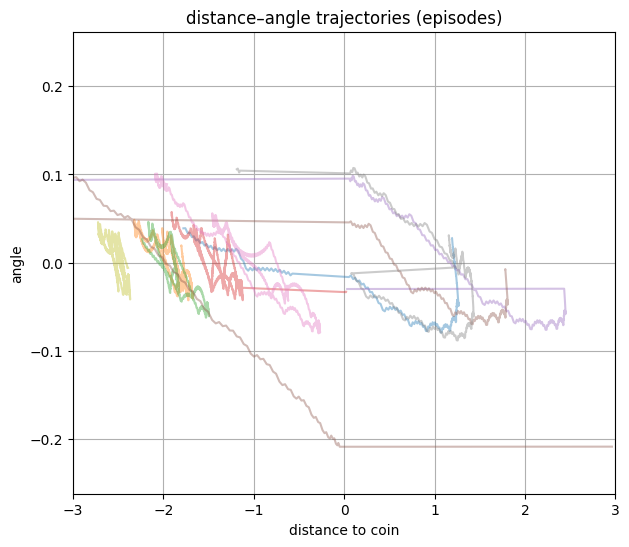

<Figure size 700x600 with 0 Axes>

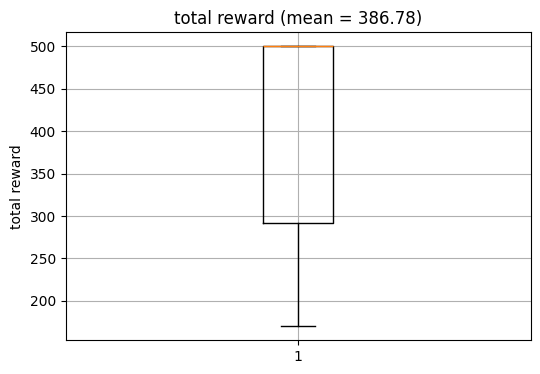

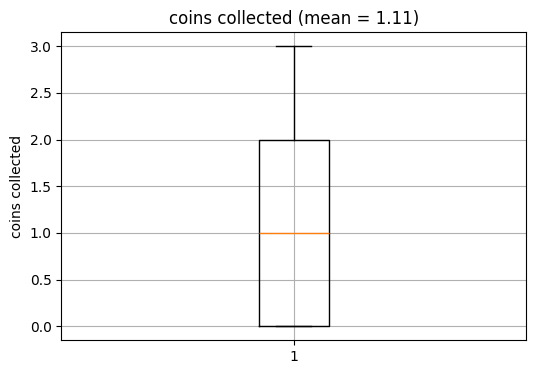

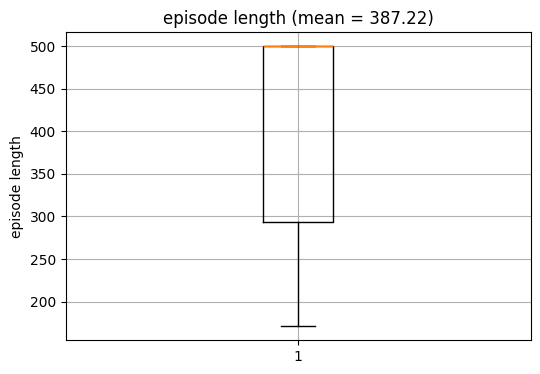

total reward: [np.int64(183), np.int64(500), np.int64(500), np.int64(500), np.int64(170), np.int64(336), np.int64(500), np.int64(292), np.int64(500)]
coins collected: [1, 0, 0, 2, 2, 3, 0, 2, 0]


In [12]:
from tqdm import tqdm

X_THRESHOLD = env.unwrapped.x_threshold*1.25 #Limite por donde se puede mover el carro
ANGLE_THRESHOLD = env.unwrapped.theta_threshold_radians*1.25 #Limite del angulo del palo
def analyze_results_simultaneous(data):
    #TODO: Completar nueva funcion pero ahora con las 20 lineas superpuestas
    # se recibe {obs, actions, rewards}, ahora uno por cada episode
    plt.figure(figsize=(7, 6))

    total_rewards = []
    coins_collected = []
    episode_lengths = []
    for ep in data:
        obs = ep["observations"]
        x = obs[:, 0]
        theta = obs[:, 2]
        coin_pos = obs[:, 4]

        distance_to_coin = x - coin_pos
        plt.plot(distance_to_coin, theta, alpha=0.4)

        total_rewards.append(np.sum(ep["rewards"]))
        coins_collected.append(ep["coins"])
        episode_lengths.append(ep["episode_length"])
    plt.xlabel("distance to coin")
    plt.ylabel("angle")
    plt.ylim(-ANGLE_THRESHOLD, ANGLE_THRESHOLD)
    plt.xlim(-X_THRESHOLD, X_THRESHOLD)
    plt.title("distance–angle trajectories (episodes)")
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(7, 6))

    # boxplot reward total
    plt.figure(figsize=(6, 4))
    plt.boxplot(total_rewards)
    plt.ylabel("total reward")
    plt.title(f"total reward (mean = {np.mean(total_rewards):.2f})")
    plt.grid(True)
    plt.show()

    # monedas
    plt.figure(figsize=(6, 4))
    plt.boxplot(coins_collected)
    plt.ylabel("coins collected")
    plt.title(f"coins collected (mean = {np.mean(coins_collected):.2f})")
    plt.grid(True)
    plt.show()

    # longitud del episodio
    plt.figure(figsize=(6, 4))
    plt.boxplot(episode_lengths)
    plt.ylabel("episode length")
    plt.title(f"episode length (mean = {np.mean(episode_lengths):.2f})")
    plt.grid(True)
    plt.show()

    print (f'total reward: {total_rewards}')
    print (f'coins collected: {coins_collected}')

    return


def evaluate_trained_model(env,model):
    #TODO: Completar funcion

    obs,_ = env.reset()
    #Hacemos un for loop por numero de test cases y guardamos resultados
    n_eval_cases = 9

    data = []
    for _ in tqdm(range(n_eval_cases)):
        done = False
        #ejecutar el primer test case i guardar
        observations = []
        actions = []
        rewards = []
        
        while not done:
            # Escoger una acción en base al modelo
            action, _ = model.predict(obs, deterministic=True)
            
            # Ejecutar la acción y esperar la respuesta del entorno
            new_obs, reward, terminated, truncated, _ = env.step(action)
    
            # Guardar informacion necesaria para poder hacer los plots despues
            observations.append(obs)
            actions.append(action)
            rewards.append(reward)
    
            obs = new_obs
            done = terminated or truncated
        data.append({
            "observations": np.array(observations),
            "actions": np.array(actions),
            "rewards": np.array(rewards),
            "episode_length": len(rewards),
            "coins":env.coins_collected
        })
            
        obs,_ = env.reset()

    #Ejecutamos la funcion analyze results
    analyze_results_simultaneous(data)

#Ejecutamos la funcion
# Aquí también he tenido que quitar el render_mode debido a los crashes
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'default',is_eval = True) #podeis modificar el render mode a None
evaluate_trained_model(eval_env,model)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>En todas las ejecuciones el movimiento del palo parece estar bien optimizado, ya que no se llega en ningún momento a +1.0 o -1.0, variando ligeramente al rededor de 0. La recompensa y la longitud de los episodios rondan en gran mayoría los 500 (steps y reward) de modo que los modelos aprenden correctamente el movimiento horizontal que permite continuar la partida hasta el truncamiento. Por otro lado la recogida de monedas varía entre 0 y 1, lo que tiene sentido con la reward default, y recogiendo en algún caso hasta dos monedas. Es normal que los modelos no suelan recoger monedas ya que a menor movimiento exagerado a derecha o izquierda, menor será el angulo del palo. Estos resultados son bastante variables entre las ejecuciones.<br>
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 1:</strong>
<br><br>
    
https://stable-baselines.readthedocs.io/en/master/modules/a2c.html

https://stable-baselines3.readthedocs.io/en/master/common/evaluation.html

https://stable-baselines3.readthedocs.io/en/master/guide/examples.html

https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html#evalcallback

PECs anteriores
</div>

# 2. Efecto del reward (3 ptos)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 2.1 (1.0 ptos):</strong> Entrena un agente usando distintos valores del parámetro coin_proximity_factor, en todos ellos manteniendo el coin_collection_reward a 10 (valor por defecto):
    <li>
    <ul>coin_proximity_factor=0</ul>
    <ul>coin_proximity_factor=0.25</ul>
    <ul>coin_proximity_factor=0.5</ul>
    <ul>coin_proximity_factor=0.75</ul>
    <ul>coin_proximity_factor=1</ul>
    </li>

Ejecuta un episodio con el mejor agente (recuerda usar los callbacks) y comenta los resultados encontrados.
</div>

In [13]:
#env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',coin_proximity_factor=)#Modificar coin_proximity_factor
#eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',coin_proximity_factor=,is_eval = True)#Modificar coin_proximity_factor

#TODO: Repetir lo mismo que en ejercicios anteriores. Callback, modelo, evaluacion inicial, carga del mejor modelo y entrenar.
#Al final, analizar resultados usando la funcion evaluate_trained_model
#Repetir para cada coin_collection_factor

STEPS = 20_000
EVAL_FREQ = 2000
EVAL_EPISODES = 20

coin_proximity_factors = [0, 0.25, 0.5, 0.75, 1.0]
results = {}

# mismo proceso de entrenamiento anterior iterando coin_proximity_factor
for cpf in coin_proximity_factors:
    env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',coin_proximity_factor=cpf)
    eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',coin_proximity_factor=cpf,is_eval = True)

    callback = EvalCallback(
        eval_env,
        best_model_save_path=f"./best_model_cpf_{cpf}/",
        eval_freq=EVAL_FREQ,
        n_eval_episodes=EVAL_EPISODES,
        deterministic=True
    )

    model = A2C(
        policy="MlpPolicy",
        env=env,
        verbose=0
    )

    # evaluación inicial
    initial_eval = evaluate_policy(
        model,
        eval_env,
        n_eval_episodes=EVAL_EPISODES,
        deterministic=True
    )

    model.learn(
        total_timesteps=STEPS,
        callback=callback
    )

    best_model = A2C.load(
        f"./best_model_cpf_{cpf}/best_model",
        env=env
    )

    # evaluación final
    final_eval = evaluate_policy(
        best_model,
        eval_env,
        n_eval_episodes=EVAL_EPISODES,
        deterministic=True
    )

    results[cpf] = {
        "initial_eval": initial_eval,
        "final_eval": final_eval,
        "model": best_model
    }

    print(f"initial eval: {initial_eval}")
    print(f"final eval:   {final_eval}")



C:\Users\Usuario\Desktop\UOC\uocvenv\Lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=2000, episode_reward=51.36 +/- 20.27
Episode length: 52.65 +/- 17.71
New best mean reward!
Eval num_timesteps=4000, episode_reward=24.80 +/- 10.65
Episode length: 25.95 +/- 11.88
Eval num_timesteps=6000, episode_reward=34.46 +/- 56.90
Episode length: 35.90 +/- 55.52
Eval num_timesteps=8000, episode_reward=475.48 +/- 7.71
Episode length: 500.00 +/- 0.00
New best mean reward!
Eval num_timesteps=10000, episode_reward=38.25 +/- 23.91
Episode length: 41.85 +/- 24.36
Eval num_timesteps=12000, episode_reward=210.77 +/- 139.71
Episode length: 210.45 +/- 140.93
Eval num_timesteps=14000, episode_reward=54.80 +/- 23.23
Episode length: 58.35 +/- 23.84
Eval num_timesteps=16000, episode_reward=167.63 +/- 128.19
Episode length: 172.15 +/- 127.89
Eval num_timesteps=18000, episode_reward=152.56 +/- 101.43
Episode length: 161.00 +/- 101.02
Eval num_timesteps=20000, episode_reward=115.48 +/- 120.37
Episode length: 118.55 +/- 121.97
initial eval: (np.float64(23.460881432890893), np.floa

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00,  9.79it/s]


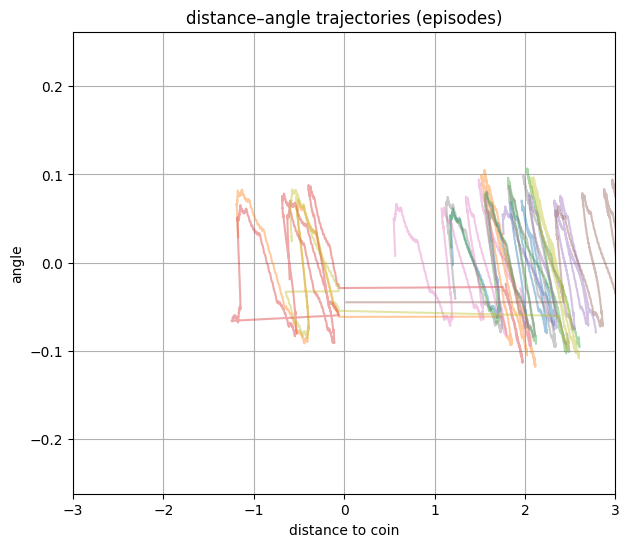

<Figure size 700x600 with 0 Axes>

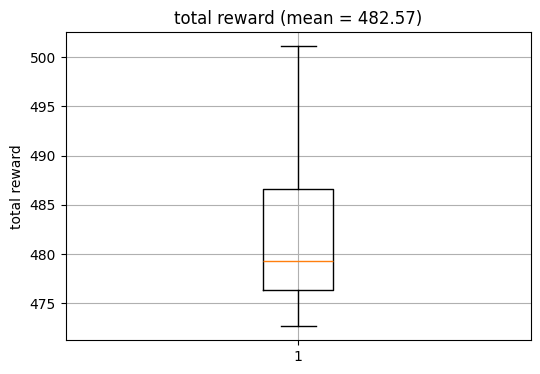

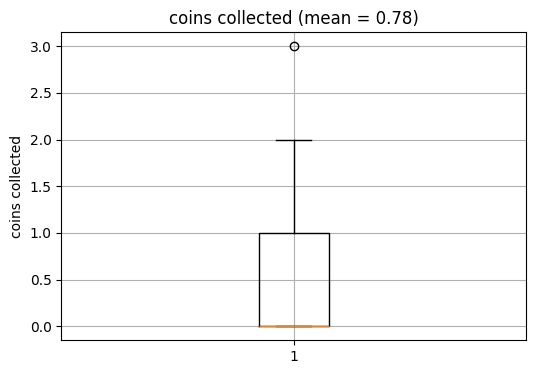

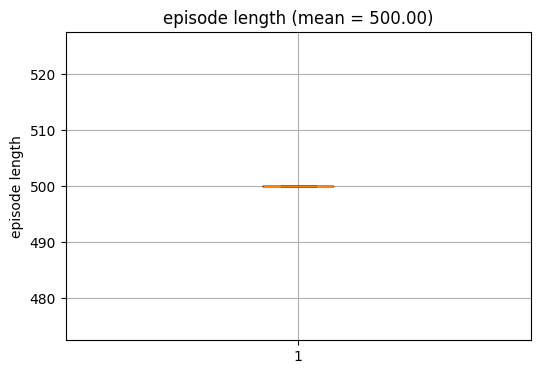

total reward: [np.float64(479.3318407107653), np.float64(479.6596929003062), np.float64(473.64657058640495), np.float64(494.5311376028139), np.float64(479.22907089576614), np.float64(486.6086310321076), np.float64(476.35441618184495), np.float64(472.6556547963149), np.float64(501.1123442025461)]
coins collected: [0, 1, 0, 2, 0, 1, 0, 0, 3]


100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 15.44it/s]


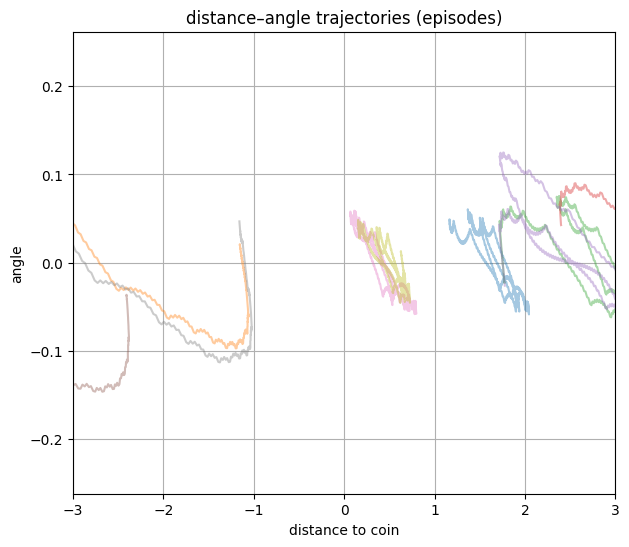

<Figure size 700x600 with 0 Axes>

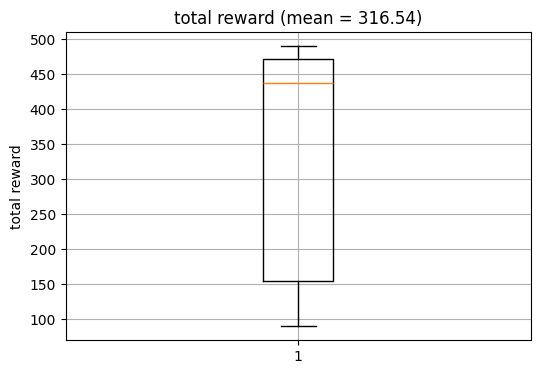

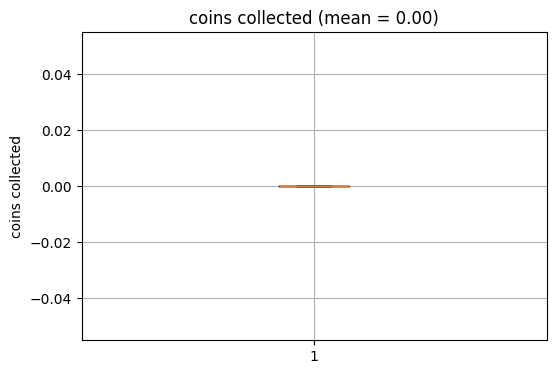

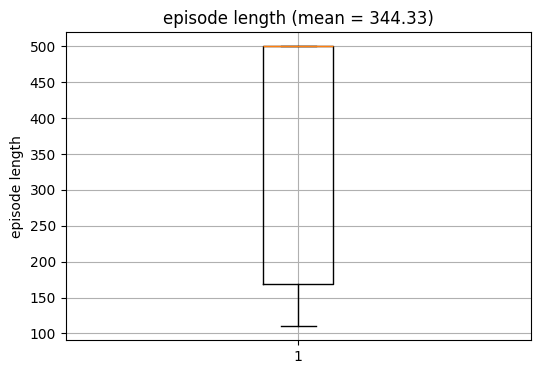

total reward: [np.float64(472.2848072340519), np.float64(156.71946620344846), np.float64(439.6921293763598), np.float64(122.48837331380237), np.float64(437.5546041219216), np.float64(89.61279909057605), np.float64(485.6033806332871), np.float64(154.89015112006973), np.float64(490.01185429985793)]
coins collected: [0, 0, 0, 0, 0, 0, 0, 0, 0]


In [14]:
# para cpf=0
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function="custom",coin_proximity_factor=0,is_eval=True)

model = A2C.load(
    "./best_model_cpf_0/best_model",
    env=eval_env
)
evaluate_trained_model(eval_env, model)


# para cpf=0.5
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function="custom",coin_proximity_factor=0.25,is_eval=True)

model = A2C.load(
    "./best_model_cpf_0.25/best_model",
    env=eval_env
)
evaluate_trained_model(eval_env, model)


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>evaluate_policy devuelve reward por episodio y longitud por episodio. Los dos mejores modelos son cpf=0, caso en el que solo importa el ángulo del palo como en anteriores ejercicios, y cpf=0.25. Como la política de solo mantener el palo en un ángulo es sencilla de aprender ya que se trata de minimizar el movimiento, esta política siempre obtiene recompensas altas y truncamiento por steps.
    
Por otro lado con cpf=0.25 aunque los resultados son peores si que se está teniendo en cuenta la moneda, pero no se está alcanzando una política eficiente en la que se recogen más monedas de las que en algunas ejecuciones se recogen por casualdiad.<br>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 2.2 (1.0 ptos):</strong> Fijando ahora coin_proximity_factor = 1, propón 2 modificaciones de la función de recompensa únicamente de la componente que tiene que ver con la recogida de monedas y comenta los resultados encontrados. Usa la misma estructura que hasta ahora (callback, modelo, evaluación inicial...).
</div>

In [15]:
env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom_1',coin_proximity_factor=1)
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom_1',coin_proximity_factor=1,is_eval = True)

#TODO: Repetir lo mismo que en ejercicios anteriores. Callback, modelo, evaluación inicial, carga del mejor modelo y entrenar.
#Al final, analizar resultados
#Repetir para las dos funciones de error nuevas.

# modificación 1 - eliminar la recompensa por cercanía
# dejo coin_proximity_factor por el enunciado pero en este caso realmente no influye
callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model_custom1/",
    eval_freq=EVAL_FREQ,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)

model = A2C(
    policy="MlpPolicy",
    env=env,
    verbose=0
)

# evaluación inicial
initial_eval_c1 = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)

model.learn(
    total_timesteps=STEPS,
    callback=callback
)

best_model = A2C.load(
    "./best_model_custom1/best_model",
    env=env
)

# evaluación final
final_eval_c1 = evaluate_policy(
    best_model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)


# modificación 2 - cambiar la formula de proximidad
env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom_2',coin_proximity_factor=1)
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom_2',coin_proximity_factor=1,is_eval = True)

callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model_custom2/",
    eval_freq=EVAL_FREQ,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)

model = A2C(
    policy="MlpPolicy",
    env=env,
    verbose=0
)

# evaluación inicial
initial_eval_c2 = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)

model.learn(
    total_timesteps=STEPS,
    callback=callback
)

best_model = A2C.load(
    "./best_model_custom2/best_model",
    env=env
)

# evaluación final
final_eval_c2 = evaluate_policy(
    best_model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)


print(f"initial eval from custom 1: {initial_eval_c1}")
print(f"final eval from custom 1:   {final_eval_c1}")

print(f"initial eval from custom 2: {initial_eval_c2}")
print(f"final eval from custom 2:   {final_eval_c2}")

C:\Users\Usuario\Desktop\UOC\uocvenv\Lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=2000, episode_reward=73.85 +/- 20.88
Episode length: 72.35 +/- 20.06
New best mean reward!
Eval num_timesteps=4000, episode_reward=27.40 +/- 19.44
Episode length: 25.90 +/- 15.46
Eval num_timesteps=6000, episode_reward=50.65 +/- 23.82
Episode length: 49.65 +/- 23.53
Eval num_timesteps=8000, episode_reward=263.00 +/- 136.32
Episode length: 251.50 +/- 136.83
New best mean reward!
Eval num_timesteps=10000, episode_reward=198.10 +/- 102.19
Episode length: 192.10 +/- 100.24
Eval num_timesteps=12000, episode_reward=469.05 +/- 65.72
Episode length: 467.55 +/- 66.30
New best mean reward!
Eval num_timesteps=14000, episode_reward=505.00 +/- 7.42
Episode length: 500.00 +/- 0.00
New best mean reward!
Eval num_timesteps=16000, episode_reward=100.25 +/- 56.73
Episode length: 99.25 +/- 56.79
Eval num_timesteps=18000, episode_reward=458.40 +/- 68.80
Episode length: 457.40 +/- 68.11
Eval num_timesteps=20000, episode_reward=260.20 +/- 103.15
Episode length: 259.20 +/- 103.67
Eval num_

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 10.68it/s]


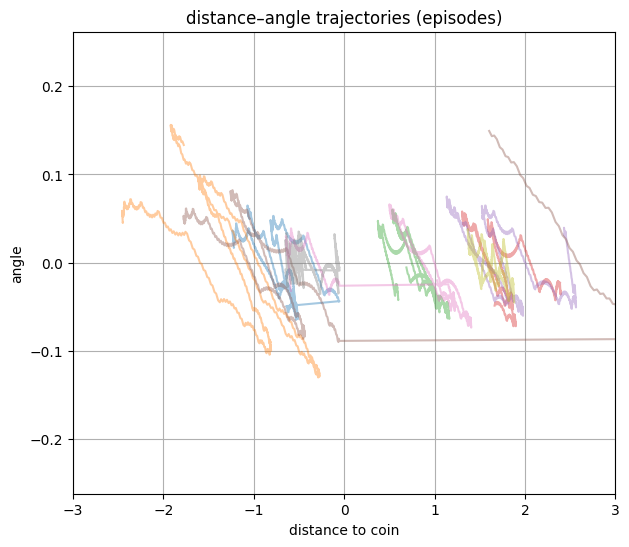

<Figure size 700x600 with 0 Axes>

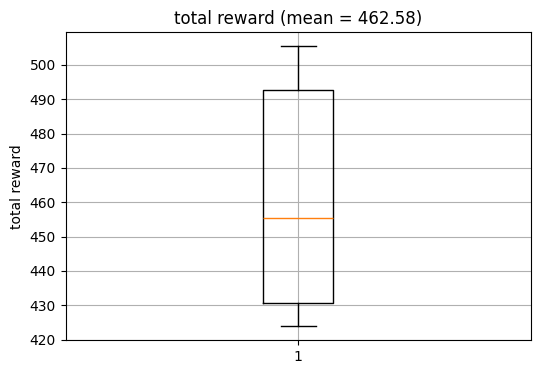

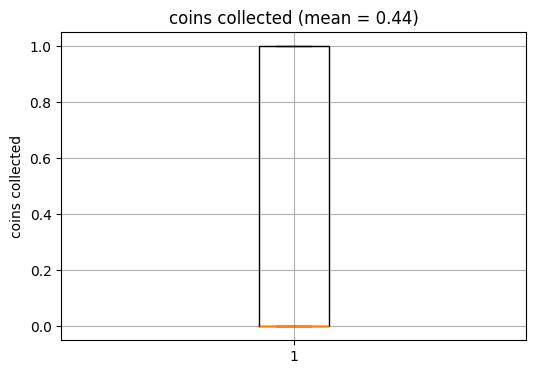

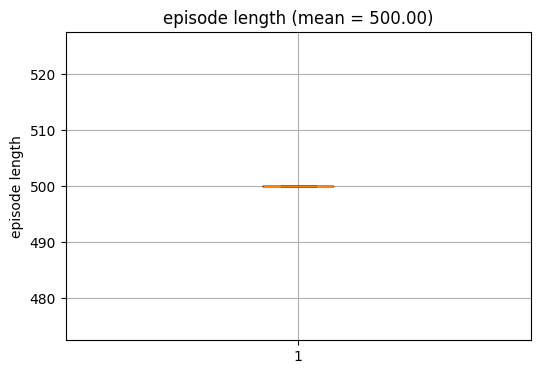

total reward: [np.float64(496.7456538146106), np.float64(455.2828830608771), np.float64(486.19558599610525), np.float64(430.55847276304394), np.float64(423.8829408775407), np.float64(430.44203523662657), np.float64(492.65174772817636), np.float64(505.4055213233822), np.float64(442.0225694556121)]
coins collected: [1, 0, 0, 0, 0, 1, 1, 1, 0]


100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 11.70it/s]


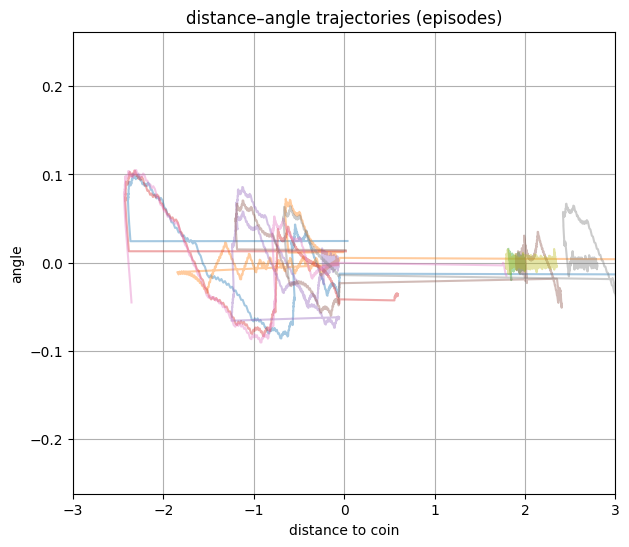

<Figure size 700x600 with 0 Axes>

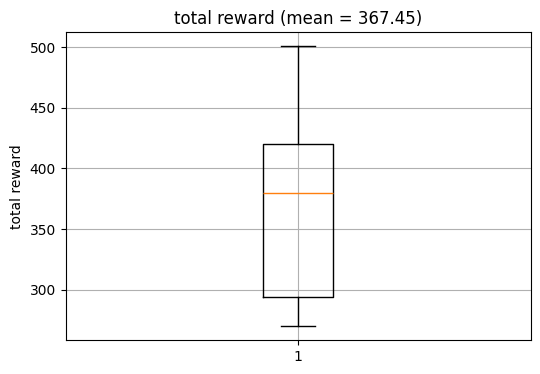

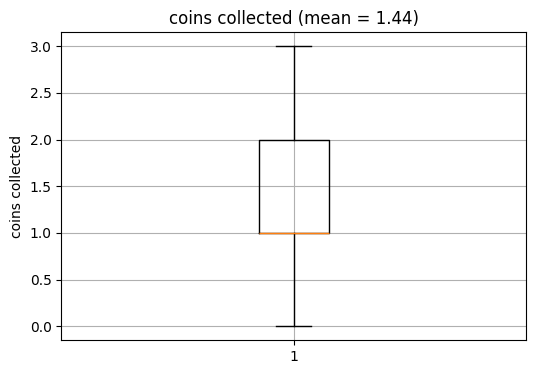

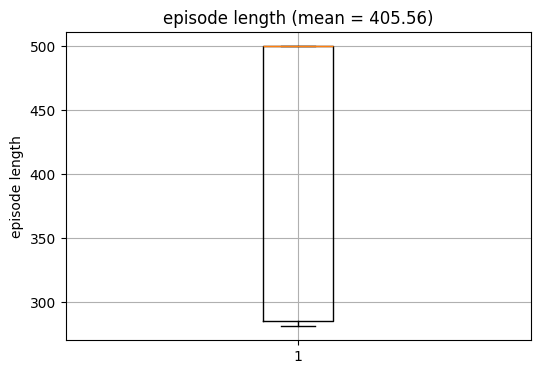

total reward: [np.float64(293.96428857793666), np.float64(295.08839297222636), np.float64(420.38656016876627), np.float64(279.1008534990696), np.float64(500.58116489916705), np.float64(459.81061514940825), np.float64(270.076284619853), np.float64(379.7082463048121), np.float64(408.2933582553301)]
coins collected: [2, 3, 0, 2, 1, 3, 1, 1, 0]


In [16]:
evaluate_trained_model(
    CartPoleEnvCoinCollection(
        render_mode=None,
        reward_function='custom',
        coin_proximity_factor=1,
        is_eval=True
    ),
    A2C.load(
    "./best_model_custom1/best_model",
    env=env
))

evaluate_trained_model(
    CartPoleEnvCoinCollection(
        render_mode=None,
        reward_function='custom',
        coin_proximity_factor=1,
        is_eval=True
    ),
    A2C.load(
    "./best_model_custom2/best_model",
    env=env
))

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>La función custom_1 obtiene mejores recompensas que custom_2, aunque los resultados no distan mucho, ya que la media de monedas recogidas es muy similar y además tampoco mejora los resultados anteriores, por lo que los cambios en la función de reward planteados no resultan muy eficientes. 
<br>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 2.3 (0.5 ptos):</strong> Fija ahora el coin_proximity_factor a 0.5 y analiza cómo varía el comportamiento del agente para 3 valores distintos del parámetro coin_collection_reward:
    <li>
    <ul>coin_collection_reward=0</ul>
    <ul>coin_collection_reward=10</ul>
    <ul>coin_collection_reward=100</ul>
    </li>

Comenta los resultados encontrados.
</div>

In [17]:
results = []
# mismo método de antes iterando sobre el reward
for coin_rew in [0, 10, 100]:
    env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',coin_proximity_factor=0.5)
    eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',coin_proximity_factor=0.5,is_eval = True)
    
    callback = EvalCallback(
        eval_env,
        best_model_save_path=f"./best_model_coinrews_{coin_rew}/",
        eval_freq=EVAL_FREQ,
        n_eval_episodes=EVAL_EPISODES,
        deterministic=True
    )
    
    model = A2C(
        policy="MlpPolicy",
        env=env,
        verbose=0
    )
    
    # evaluación inicial
    initial_eval = evaluate_policy(
        model,
        eval_env,
        n_eval_episodes=EVAL_EPISODES,
        deterministic=True
    )
    
    model.learn(
        total_timesteps=STEPS,
        callback=callback
    )
    
    best_model = A2C.load(
        f"./best_model_coinrews_{coin_rew}/best_model.zip", 
        #no se si hay diferencia al cargar el modelo mediante zip o sin la extensión
        #solo me ha dado problemas aquí
        env=env
    )
    
    # evaluación final
    final_eval = evaluate_policy(
        best_model,
        eval_env,
        n_eval_episodes=EVAL_EPISODES,
        deterministic=True
    )

    results.append([coin_rew, initial_eval, final_eval])

for result in results:
    print(f"Results for coin_reward={result[0]}")
    print(f"initial eval: {result[1]}")
    print(f"final eval:   {result[2]}")


C:\Users\Usuario\Desktop\UOC\uocvenv\Lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=2000, episode_reward=44.64 +/- 32.64
Episode length: 49.90 +/- 38.01
New best mean reward!
Eval num_timesteps=4000, episode_reward=104.05 +/- 67.74
Episode length: 110.65 +/- 68.61
New best mean reward!
Eval num_timesteps=6000, episode_reward=104.99 +/- 88.86
Episode length: 119.25 +/- 94.82
New best mean reward!
Eval num_timesteps=8000, episode_reward=78.20 +/- 35.08
Episode length: 84.60 +/- 34.78
Eval num_timesteps=10000, episode_reward=82.70 +/- 41.77
Episode length: 90.20 +/- 43.55
Eval num_timesteps=12000, episode_reward=118.49 +/- 159.85
Episode length: 127.50 +/- 160.27
New best mean reward!
Eval num_timesteps=14000, episode_reward=171.39 +/- 122.61
Episode length: 186.90 +/- 136.37
New best mean reward!
Eval num_timesteps=16000, episode_reward=219.35 +/- 120.46
Episode length: 230.80 +/- 136.05
New best mean reward!
Eval num_timesteps=18000, episode_reward=197.71 +/- 218.73
Episode length: 201.75 +/- 222.75
Eval num_timesteps=20000, episode_reward=180.47 +/-

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>
Results for coin_reward=10
initial eval: (np.float64(10.037760362029076), np.float64(4.330891613008424))
final eval:   (np.float64(376.31058571338656), np.float64(99.07696904260658))

la recompensa más alta se obtiene con coin_reward=10, lo que tiene sentido ya que si se recompensa en exceso con cr=100 el número de steps se reducen, lo que puede pasar al recompensar la temeridad de moverse más de lo necesario para alcanzar las monedas. En el caso de cr=0 se maximizan los steps pero se ve afectada la recompensa, mientras que utilizando cr=100 los steps se reducen en exceso, y la recompensa también sufre al no continuar la partida.
    
<br>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 2.4 (0.5 ptos):</strong> Haz un pequeño análisis de cómo crees que deben ser las características del reward para un comportamiento óptimo del agente.
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
Continuando con el comentario anterior, para optimizar los parámetros en el caso del juego que incluye la recogida de monedas, habría que encontrar un equilibrio entre ellos que cumplan:
    
    1. Se recompensa suficientemente la recogida de monedas como para evitar que se priorice en exceso realizar movimientos minimos para mantener el palo en un angulo minimo.
    2. Se recompensa hasta cierto punto el aproximamiento a una moneda, de modo que se obtenga una recompensa también al acercarse manteniendo el palo, con el objetivo de no favorecer demasiado la temeridad.

Además, creo que también podría ser interesante añadir recompensas extra según el ángulo del palo en la recogida de las monedas, de modo que si se recoge una moneda arriesgando la caida del palo se obtenga una recompensa menor que si se recoge manteniendo el palo en un angulo cercano a cero. Esto podría plausiblemente aumentar los steps de la partida, que es algo que resulta problemático en esta variación del juego.
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 2:</strong>
<br><br>
Ejercicios anteriores
</div>

# 3. Incremento del espacio acciones (1.5 ptos)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 3.1 (0.5 ptos):</strong> Modifica el código de tal forma que ahora existan 6 en vez de 2 acciones:
    <ul>
    <li>Acciones 6,5,4, hacer 100%,66% y 33% de fuerza positiva respectivamente</li>
    <li>Acciones 1,2,3 hacer 100%,66% y 33% de fuerza negativa respectivamente</li>
    </ul>

Usa coin_proximity_factor = 0.5 y coin_collection_reward = 10
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 3.2 (1 ptos):</strong> Ejecuta un entrenamiento y analiza los resultados. ¿Por qué han ido mejor/peor? ¿Es lo que esperabas?
</VSCode.Cell>

In [18]:
#implementar antes los TODO del entorno
env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',increased_actions = True,coin_proximity_factor = 0.5, coin_collection_reward = 10)
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',increased_actions = True,coin_proximity_factor = 0.5, coin_collection_reward = 10,is_eval = True)

#TODO: Repetir lo mismo que en ejercicion anteriores. Callback, modelo, evaluacion inicial, carga del mejor modelo y entrenar.
#Al final, analizar resultados
callback = EvalCallback(
    eval_env,
    best_model_save_path=f"./best_model_6actions/",
    eval_freq=EVAL_FREQ,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)

model = A2C(
    policy="MlpPolicy",
    env=env,
    verbose=0
)

# evaluación inicial
initial_eval = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)

model.learn(
    total_timesteps=STEPS,
    callback=callback
)

best_model = A2C.load(
    f"./best_model_6actions/best_model",
    env=env
)

# evaluación final
final_eval = evaluate_policy(
    best_model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True
)

print(f"initial eval: {initial_eval}")
print(f"final eval:   {final_eval}")

Eval num_timesteps=2000, episode_reward=25.63 +/- 17.61
Episode length: 27.25 +/- 16.33
New best mean reward!
Eval num_timesteps=4000, episode_reward=44.95 +/- 17.93
Episode length: 50.40 +/- 19.28
New best mean reward!
Eval num_timesteps=6000, episode_reward=46.84 +/- 33.92
Episode length: 50.05 +/- 36.06
New best mean reward!
Eval num_timesteps=8000, episode_reward=76.84 +/- 51.08
Episode length: 85.45 +/- 59.46
New best mean reward!
Eval num_timesteps=10000, episode_reward=114.54 +/- 90.66
Episode length: 122.00 +/- 100.84
New best mean reward!
Eval num_timesteps=12000, episode_reward=122.72 +/- 89.10
Episode length: 135.80 +/- 92.78
New best mean reward!
Eval num_timesteps=14000, episode_reward=77.56 +/- 21.25
Episode length: 85.05 +/- 21.70
Eval num_timesteps=16000, episode_reward=57.29 +/- 10.65
Episode length: 64.75 +/- 12.57
Eval num_timesteps=18000, episode_reward=41.47 +/- 7.35
Episode length: 46.30 +/- 7.48
Eval num_timesteps=20000, episode_reward=62.33 +/- 55.44
Episode len

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 40.85it/s]


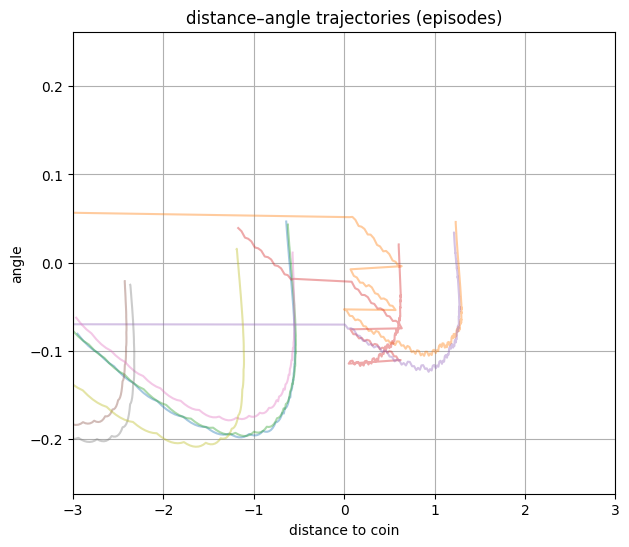

<Figure size 700x600 with 0 Axes>

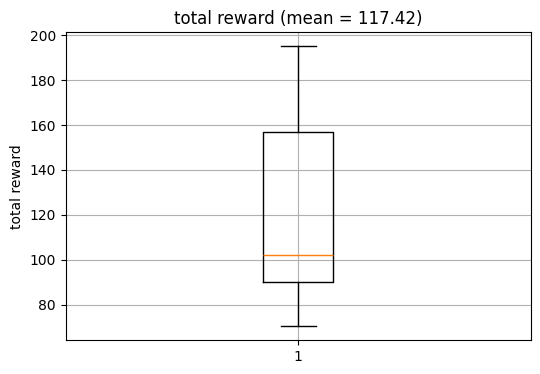

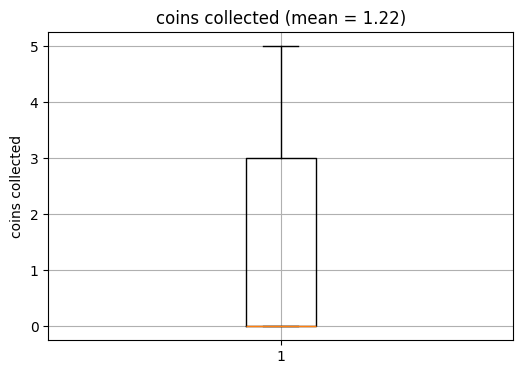

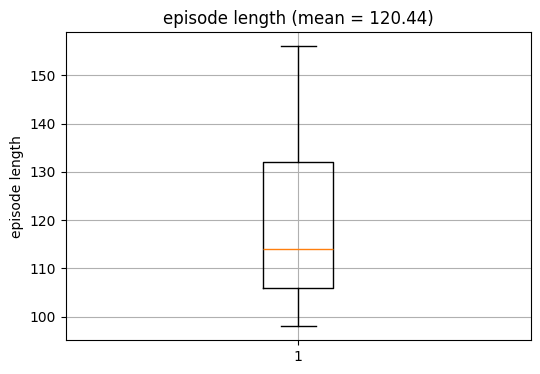

total reward: [np.float64(102.21540184861455), np.float64(195.00366041130513), np.float64(105.03330581489054), np.float64(156.7493783454009), np.float64(168.70669390819472), np.float64(71.68174596782936), np.float64(96.81456915399343), np.float64(70.41938817267626), np.float64(90.13822196349241)]
coins collected: [0, 5, 0, 3, 3, 0, 0, 0, 0]


In [19]:
evaluate_trained_model(
    CartPoleEnvCoinCollection(
        render_mode=None,
        reward_function='custom',
        increased_actions=True,
        coin_proximity_factor=0.5,
        coin_collection_reward=10,
        is_eval=True
    ),
    best_model
)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>Aunque podemos ver que el agente si aprende a ir en la dirección de la moneda, la minimización del movimiento del palo requiere fuerzas pequeñas, mientras que el desplazamiento necesita movimientos más bruscos. La introducción de nuevas acciones posibles parece introducir también una dificultad para el agente de controlar el movimiento, por lo que parece que el agente aprende a moverse en la dirección a la moneda de forma exponencial en muchos steps, aumentando la brusquedad del movimiento sin llegar a obtener la moneda.  <br>
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 3:</strong>
<br><br>
PECs anteriores.
</div>

# 4. Búsqueda de hiperparámetros (1.5 ptos)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 4.1 (1 ptos):</strong> Usando el entorno con coin_collection_factor = 0.75 y con las acciones default (no ampliadas), busca los hiperparámetros del modelo para que este aprenda en menos de 10 mil steps. Te damos algunas pistas de qué rango de valores merece la pena explorar:
    <ul>
    <li>gamma = (0.9,0.999).Se recomienda búsqueda en escala logarítmica</li>
    <li>max_grad_norm = (0.3,5.0). Se recomienda búsqueda en escala logarítmica</li>
    <li>n_steps = (8,32)</li>
    <li>learning_rate = (1e-5,1e-1). Se recomienda búsqueda en escala logarítmica</li>
    <li>ent_coef = (1e-8,1e-3). Se recomienda búsqueda en escala logarítmica</li>
    </ul>
    Importante: La búsqueda de hiperparámetros se debe de poder hacer en 100 pasos, es decir, solo habría que entrenar el modelo con 100 combinaciones distintas de hiperparámetros, nada más.
    
Explica la estrategia de búsqueda que se ha seguido. Si se usa una estrategia dummy tipo grid search, la puntuación máxima va a ser de 0.5/1 puntos. Para conseguir la máxima puntuación, podéis usar frameworks como [optuna](https://optuna.org/#code_examples) para hacer la optimización de hiperparámetros.
</div>

In [28]:
import optuna
STEPS = 10_000 #BAJAMOS LOS STEPS A 10_000 para la búsqueda de hiperparámetros
EVAL_EPISODES = 18
EVAL_FREQ = 2_000
N_TRIALS = 100 #Solo haremos 100 trials de combinaciones de hiperparámetros


def objective(trial):
    gamma = trial.suggest_float("gamma", 0.9, 0.999, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    ent_coef = trial.suggest_float("ent_coef", 1e-8, 1e-3, log=True)
    max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 5.0, log=True)
    n_steps = trial.suggest_int("n_steps", 8, 32)

    env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',increased_actions = False,coin_proximity_factor=1,is_eval = True)
    eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',increased_actions = False,coin_proximity_factor=1)

    model = A2C(
        policy="MlpPolicy",
        env=env,
        gamma=gamma,
        learning_rate=learning_rate,
        ent_coef=ent_coef,
        max_grad_norm=max_grad_norm,
        n_steps=n_steps,
        verbose=0
    )

    model.learn(total_timesteps=STEPS)

    mean_reward, _ = evaluate_policy(
        model,
        eval_env,
        n_eval_episodes=EVAL_EPISODES,
        deterministic=True
    )

    return mean_reward


In [30]:
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',increased_actions = False,coin_proximity_factor=1,is_eval = True)

#TODO: Buscamos hiperparámetros
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)

print("mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"{k}: {v:.5g}")

[I 2026-01-15 11:47:36,702] A new study created in memory with name: no-name-b13686ba-0a61-4db4-9d11-304954efff9a
[I 2026-01-15 11:47:42,194] Trial 0 finished with value: 11.199556234810087 and parameters: {'gamma': 0.9467281043238431, 'learning_rate': 0.0157800652750342, 'ent_coef': 2.6989609198840504e-05, 'max_grad_norm': 0.3982537756240842, 'n_steps': 19}. Best is trial 0 with value: 11.199556234810087.
[I 2026-01-15 11:47:47,103] Trial 1 finished with value: 8.905699961715275 and parameters: {'gamma': 0.9825920329866734, 'learning_rate': 0.01753200644816296, 'ent_coef': 0.0001567383420509716, 'max_grad_norm': 2.3965370849611594, 'n_steps': 32}. Best is trial 0 with value: 11.199556234810087.
[I 2026-01-15 11:47:54,059] Trial 2 finished with value: 436.7798246939977 and parameters: {'gamma': 0.9630714921219342, 'learning_rate': 0.0006764370682065915, 'ent_coef': 0.00023313107827241392, 'max_grad_norm': 1.5278348089547307, 'n_steps': 23}. Best is trial 2 with value: 436.7798246939977

mejores hiperparámetros:
gamma: 0.97649
learning_rate: 0.0019872
ent_coef: 5.1091e-08
max_grad_norm: 3.9764
n_steps: 15


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>

Un gamma más alto prioriza las recompensas futuras sobre las inmediatas, lo que tiene sentido en el caso de la recogida de monedas, pero si se aumenta en exceso puede resultar en fallos a corto plazo. Además, el lr encontrado también encaja con entornos cambiantes. En general, los parámetros encontrados parecen consistentes con lo observado en los ejercicios anteriores y los comentarios. Parece que los parámetros encontrados dependen en buena parte de la aleatoriedad de cada ejecución, lo que puede ser un problema para obtener resultados consistentes.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 4.2 (0.5 ptos):</strong> Ahora vuelve a entrenar un modelo durante 50_000 steps y analiza los resultados encontrados, esta vez usando 100 entornos de evaluación. Solo se conseguirán los 0.5 puntos si, de media, se recolectan más de 1.6 coins por episodio con una longitud promedio de más de 400.
</VSCode.Cell>

In [31]:
STEPS = 50_000
env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',increased_actions = False,coin_proximity_factor=0.75)
eval_env = CartPoleEnvCoinCollection(render_mode=None,reward_function = 'custom',increased_actions = False,coin_proximity_factor=0.75,is_eval = True)

#TODO: Repetir lo mismo que en ejercicios anteriores. Callback, modelo, evaluación inicial, carga del mejor modelo y entrenar.
#Recordad poner los mejores hiperparámetros encontrados hasta ahora.
#Al final, analizar resultados
#TODO: Buscamos hiperparámetros
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)

print("mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"{k}: {v:.5g}")

[I 2026-01-15 11:57:35,410] A new study created in memory with name: no-name-d707e9a7-eb8c-4a48-8f4f-9c40764eace1
[I 2026-01-15 11:57:58,204] Trial 0 finished with value: 270.7979081515223 and parameters: {'gamma': 0.9970670383925162, 'learning_rate': 0.0014042698371252334, 'ent_coef': 2.499923807789993e-08, 'max_grad_norm': 2.2782707570096417, 'n_steps': 32}. Best is trial 0 with value: 270.7979081515223.
[I 2026-01-15 11:58:20,942] Trial 1 finished with value: 142.04386470384068 and parameters: {'gamma': 0.9621601955455281, 'learning_rate': 0.000437275429802296, 'ent_coef': 1.0835315776695654e-08, 'max_grad_norm': 4.176581454046234, 'n_steps': 28}. Best is trial 0 with value: 270.7979081515223.
[I 2026-01-15 11:58:46,532] Trial 2 finished with value: 51.027092423703934 and parameters: {'gamma': 0.9704081046029877, 'learning_rate': 0.07891478664303352, 'ent_coef': 4.895435591950586e-08, 'max_grad_norm': 4.058607362599221, 'n_steps': 15}. Best is trial 0 with value: 270.7979081515223.


mejores hiperparámetros:
gamma: 0.98224
learning_rate: 0.0042429
ent_coef: 8.4478e-08
max_grad_norm: 3.5702
n_steps: 14


In [35]:
EVAL_EPISODES = 100

callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model_ex4_2/",
    eval_freq=EVAL_FREQ,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True,
)

model = A2C( 
    policy="MlpPolicy",
    env=env,
    gamma= 0.98224,
    learning_rate= 0.0042429,
    ent_coef= 8.4478e-08,
    max_grad_norm= 3.5702,
    n_steps= 14,
    verbose=0,
)

initial_eval = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True,
)

model.learn(
    total_timesteps=STEPS,
    callback=callback,
)

best_model = A2C.load(
    "./best_model_ex4_2/best_model",
    env=env,
)

final_eval = evaluate_policy(
    best_model,
    eval_env,
    n_eval_episodes=EVAL_EPISODES,
    deterministic=True,
)

mean_reward, std_reward = final_eval

coins = []
lengths = []

for _ in range(EVAL_EPISODES):
    obs, _ = eval_env.reset()
    done = False
    truncated = False
    while not (done or truncated):
        action, _ = best_model.predict(obs, deterministic=True)
        obs, _, done, truncated, _ = eval_env.step(action)
    coins.append(eval_env.coins_collected)
    lengths.append(eval_env.steps)

print(f"Initial eval reward: {initial_eval}")
print(f"Final eval reward:   {final_eval}")
print(f"Mean coins:   {np.mean(coins)}")
print(f"Mean length:  {np.mean(lengths)}")

Eval num_timesteps=2000, episode_reward=451.13 +/- 47.77
Episode length: 500.00 +/- 0.00
New best mean reward!
Eval num_timesteps=4000, episode_reward=46.74 +/- 49.85
Episode length: 49.12 +/- 52.02
Eval num_timesteps=6000, episode_reward=452.68 +/- 40.19
Episode length: 500.00 +/- 0.00
New best mean reward!
Eval num_timesteps=8000, episode_reward=386.70 +/- 88.39
Episode length: 484.86 +/- 36.30
Eval num_timesteps=10000, episode_reward=140.44 +/- 119.30
Episode length: 161.99 +/- 119.10
Eval num_timesteps=12000, episode_reward=116.38 +/- 105.53
Episode length: 134.42 +/- 105.00
Eval num_timesteps=14000, episode_reward=80.46 +/- 62.51
Episode length: 91.48 +/- 69.49
Eval num_timesteps=16000, episode_reward=196.47 +/- 123.40
Episode length: 231.79 +/- 110.76
Eval num_timesteps=18000, episode_reward=422.64 +/- 62.52
Episode length: 490.29 +/- 25.55
Eval num_timesteps=20000, episode_reward=445.69 +/- 38.05
Episode length: 489.04 +/- 30.95
Eval num_timesteps=22000, episode_reward=255.57 +/

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentario:</strong>
<br>Los parámetros encontrados no parecen ser adecuados para que el agente aprenda a recoger las monedas en lugar de mantener el palo hasta el truncamiento.<br>
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 4:</strong>
<br><br>
https://medium.com/@taeefnajib/hyperparameter-tuning-using-optuna-c46d7b29a3e

https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/002_configurations.html

https://www.reinforcementlearningpath.com/discount-factor-explained-why-gamma-%CE%B3-makes-or-breaks-learning-q-learning-cartpole-case-study#What-is-the-Discount-Factor

https://stable-baselines.readthedocs.io/en/master/modules/a2c.html
</div>